<a href="https://colab.research.google.com/github/preetidehingia02-ui/PRODUCTION-FORECASTING-PYTHON-CODE/blob/main/PRODUCTIONFORECASTING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""Improved Oil Production Forecasting with Proper Time Series Handling

This notebook implements best practices for time series forecasting:
- No data leakage
- Proper train-test splitting
- Multiple lagged features
- Model regularization
- Comprehensive evaluation
"""

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set plot style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 80)
print("OIL PRODUCTION FORECASTING - IMPROVED VERSION")
print("=" * 80)


OIL PRODUCTION FORECASTING - IMPROVED VERSION


# ============================================
# STEP 1: LOAD DATA
# ============================================

In [30]:
print("\n[1/8] Loading data...")

# Load the dataset from the provided URL
df = pd.read_csv('https://raw.githubusercontent.com/Divyanshu-ISM/Machine-Learning-Deep-Learning/main/Volve%20P-12_DatesCorrected.csv',
                index_col=0,
                parse_dates=True)

print(f"✓ Data loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Date range: {df.index.min()} to {df.index.max()}")



[1/8] Loading data...
✓ Data loaded successfully: 3291 rows, 14 columns
  Date range: 2007-01-09 00:00:00 to 2016-01-12 00:00:00


# ============================================
# STEP 2: SPLIT DATA BY DATE (CRITICAL!)
# ============================================

In [31]:
print("\n[2/8] Splitting data by date...")

# Split BEFORE any transformations to prevent data leakage
df_train_original = df[df.index.year <= 2014].copy()
df_test_original = df[df.index.year >= 2015].copy()

print(f"✓ Training set: {df_train_original.shape[0]} rows ({df_train_original.index.min()} to {df_train_original.index.max()})")
print(f"✓ Testing set: {df_test_original.shape[0]} rows ({df_test_original.index.min()} to {df_test_original.index.max()})")

# Select only the target column
df_train = df_train_original[['BORE_OIL_VOL']].copy()
df_test = df_test_original[['BORE_OIL_VOL']].copy()


[2/8] Splitting data by date...
✓ Training set: 2914 rows (2007-01-09 00:00:00 to 2014-12-31 00:00:00)
✓ Testing set: 377 rows (2015-01-01 00:00:00 to 2016-01-12 00:00:00)


# ============================================
# STEP 3: VISUALIZE ORIGINAL DATA
# ============================================


[3/8] Visualizing original data...


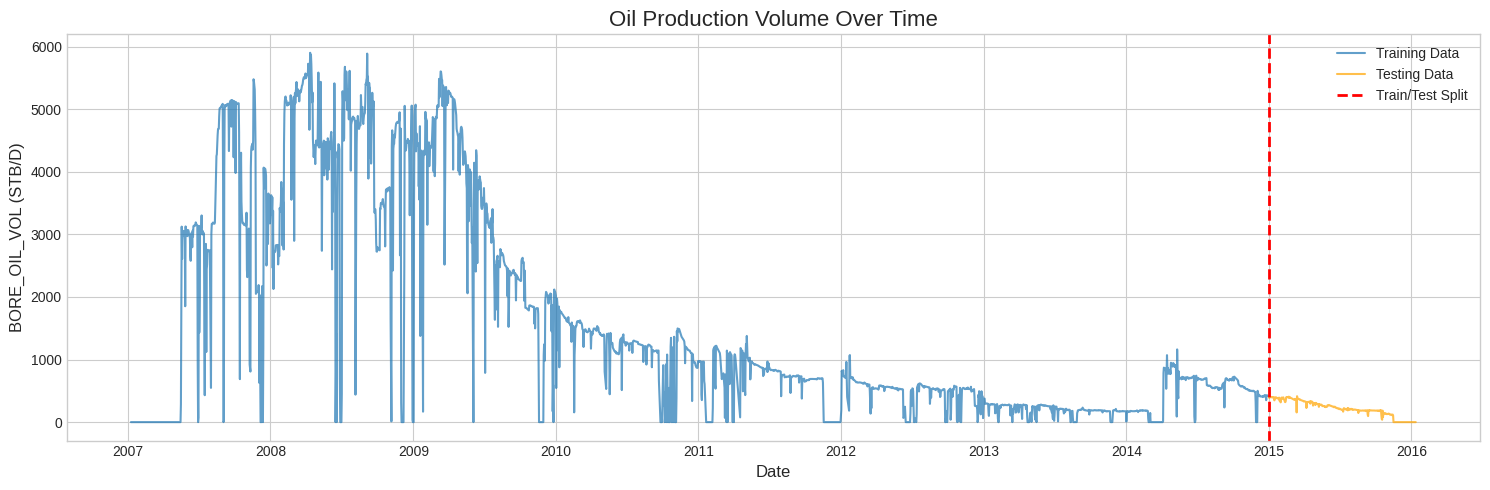

In [32]:
print("\n[3/8] Visualizing original data...")

plt.figure(figsize=(15, 5))
plt.plot(df_train.index, df_train['BORE_OIL_VOL'], label='Training Data', alpha=0.7)
plt.plot(df_test.index, df_test['BORE_OIL_VOL'], label='Testing Data', alpha=0.7, color='orange')
plt.axvline(df_test.index[0], color='red', linestyle='--', linewidth=2, label='Train/Test Split')
plt.title('Oil Production Volume Over Time', size=16)
plt.xlabel('Date', size=12)
plt.ylabel('BORE_OIL_VOL (STB/D)', size=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================
# STEP 4: FEATURE ENGINEERING
# ============================================

In [33]:
print("\n[4/8] Creating features...")

def create_features(df, n_lags=10, use_advanced=True):
    """
    Create lagged features and rolling statistics for time series forecasting.

    Parameters:
    - df: DataFrame with time series data
    - n_lags: Number of lagged features to create
    - use_advanced: Whether to include advanced features (rolling stats, time features)

    Returns:
    - DataFrame with added features
    """
    df_features = df.copy()
    target_col = df.columns[0]

    # Create lagged features
    for i in range(1, n_lags + 1):
        df_features[f'lag_{i}'] = df[target_col].shift(i)

    if use_advanced:
        # Rolling statistics (calculate on past data only using shift)
        for window in [7, 14, 30]:
            df_features[f'rolling_mean_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).mean()
            df_features[f'rolling_std_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).std()
            df_features[f'rolling_min_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).min()
            df_features[f'rolling_max_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).max()

        # Exponential moving average
        df_features['ema_7'] = df[target_col].shift(1).ewm(span=7, adjust=False).mean()
        df_features['ema_30'] = df[target_col].shift(1).ewm(span=30, adjust=False).mean()

        # Time-based features
        df_features['day_of_week'] = df.index.dayofweek
        df_features['month'] = df.index.month
        df_features['quarter'] = df.index.quarter
        df_features['day_of_year'] = df.index.dayofyear

    return df_features

# Apply feature engineering to train and test sets SEPARATELY
n_lags = 10
df_train_features = create_features(df_train, n_lags=n_lags, use_advanced=True)
df_test_features = create_features(df_test, n_lags=n_lags, use_advanced=True)

print(f"✓ Created {df_train_features.shape[1] - 1} features")
print(f"  - {n_lags} lagged features")
print(f"  - Rolling statistics (7, 14, 30 days)")
print(f"  - Exponential moving averages")
print(f"  - Time-based features")

# Remove rows with NaN values
df_train_features = df_train_features.dropna()
df_test_features = df_test_features.dropna()

print(f"✓ After removing NaN:")
print(f"  - Training set: {df_train_features.shape[0]} rows")
print(f"  - Testing set: {df_test_features.shape[0]} rows")

# Separate features (X) and target (y)
X_train = df_train_features.drop('BORE_OIL_VOL', axis=1)
y_train = df_train_features['BORE_OIL_VOL']

X_test = df_test_features.drop('BORE_OIL_VOL', axis=1)
y_test = df_test_features['BORE_OIL_VOL']

print(f"\n✓ Final shapes:")
print(f"  - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  - X_test: {X_test.shape}, y_test: {y_test.shape}")



[4/8] Creating features...
✓ Created 28 features
  - 10 lagged features
  - Rolling statistics (7, 14, 30 days)
  - Exponential moving averages
  - Time-based features
✓ After removing NaN:
  - Training set: 2904 rows
  - Testing set: 367 rows

✓ Final shapes:
  - X_train: (2904, 28), y_train: (2904,)
  - X_test: (367, 28), y_test: (367,)


# ============================================
# STEP 5: TRAIN MODEL WITH REGULARIZATION
# ============================================

In [34]:
print("\n[5/8] Training Random Forest model with regularization...")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Random Forest with regularization to prevent overfitting
rf = RandomForestRegressor(
    n_estimators=50,          # Reduced number of trees
    max_depth=10,             # Limit tree depth
    min_samples_split=20,     # Require more samples to split
    min_samples_leaf=10,      # Require more samples in leaf nodes
    max_features='sqrt',      # Use subset of features
    random_state=42,
    n_jobs=-1                 # Use all CPU cores
)

# Train the model
rf.fit(X_train, y_train)
print("✓ Model training completed")


[5/8] Training Random Forest model with regularization...
✓ Model training completed


# ============================================
# STEP 6: MAKE PREDICTIONS
# ============================================

In [35]:
print("\n[6/8] Making predictions...")

yp_train = rf.predict(X_train)
yp_test = rf.predict(X_test)

print("✓ Predictions completed")


[6/8] Making predictions...
✓ Predictions completed


# ============================================
# STEP 7: EVALUATE MODEL
# ============================================

In [36]:
print("\n[7/8] Evaluating model performance...")

# Training metrics
train_rmse = np.sqrt(mean_squared_error(y_train, yp_train))
train_mae = mean_absolute_error(y_train, yp_train)
train_r2 = r2_score(y_train, yp_train)

# Testing metrics
test_rmse = np.sqrt(mean_squared_error(y_test, yp_test))
test_mae = mean_absolute_error(y_test, yp_test)
test_r2 = r2_score(y_test, yp_test)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  - RMSE: {train_rmse:.2f} STB/D")
print(f"  - MAE:  {train_mae:.2f} STB/D")
print(f"  - R²:   {train_r2:.4f}")

print(f"\nTesting Set:")
print(f"  - RMSE: {test_rmse:.2f} STB/D")
print(f"  - MAE:  {test_mae:.2f} STB/D")
print(f"  - R²:   {test_r2:.4f}")

# Check for overfitting
overfitting_ratio = test_rmse / train_rmse
print(f"\nOverfitting Analysis:")
print(f"  - Test RMSE / Train RMSE = {overfitting_ratio:.2f}")
if overfitting_ratio < 1.3:
    print("  ✓ Good generalization - minimal overfitting")
elif overfitting_ratio < 1.8:
    print("  ⚠️ Moderate overfitting detected")
else:
    print("  ❌ Significant overfitting - model may need adjustment")

print("=" * 60)


[7/8] Evaluating model performance...

MODEL PERFORMANCE METRICS

Training Set:
  - RMSE: 378.99 STB/D
  - MAE:  163.30 STB/D
  - R²:   0.9494

Testing Set:
  - RMSE: 31.83 STB/D
  - MAE:  22.37 STB/D
  - R²:   0.9325

Overfitting Analysis:
  - Test RMSE / Train RMSE = 0.08
  ✓ Good generalization - minimal overfitting


# ============================================
# STEP 8: VISUALIZATIONS
# ============================================


[8/8] Creating visualizations...


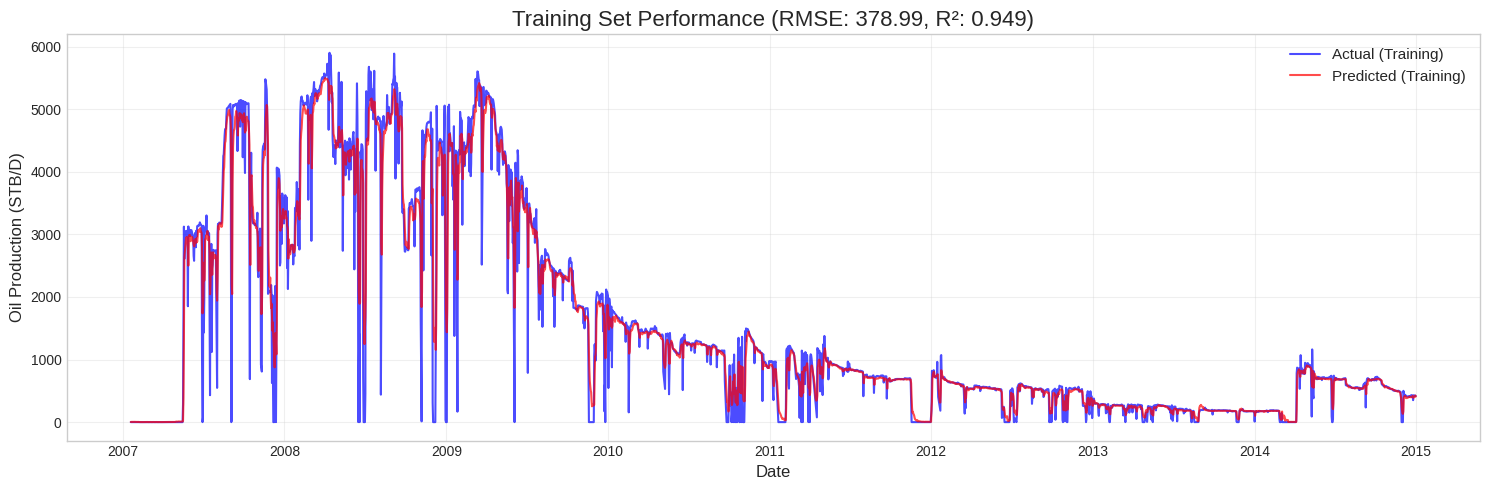

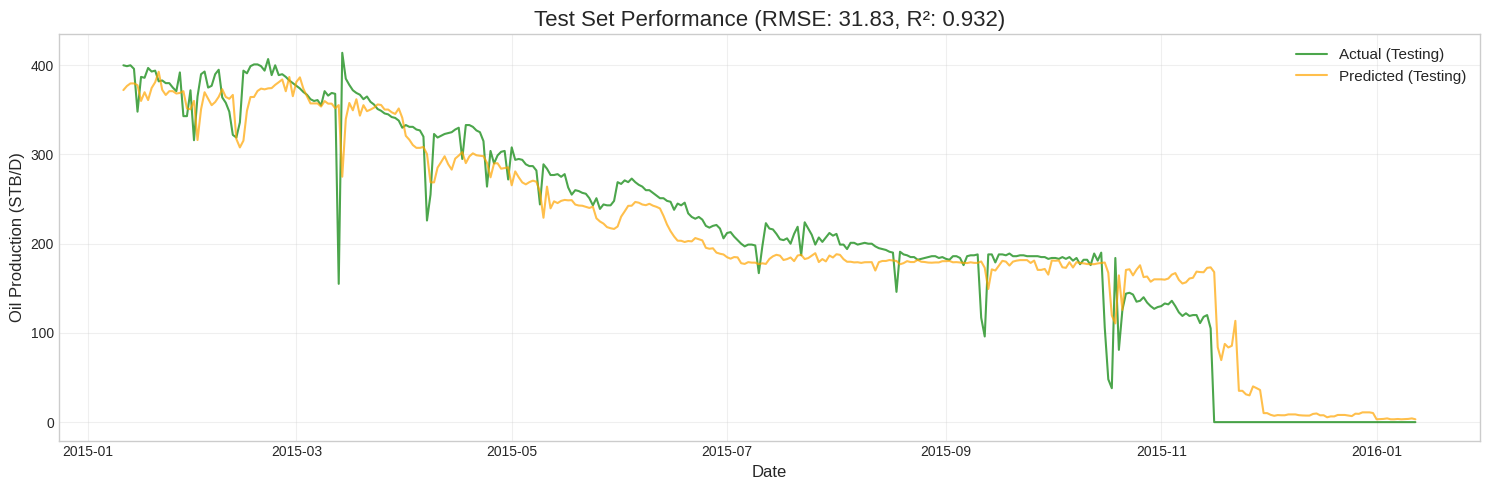

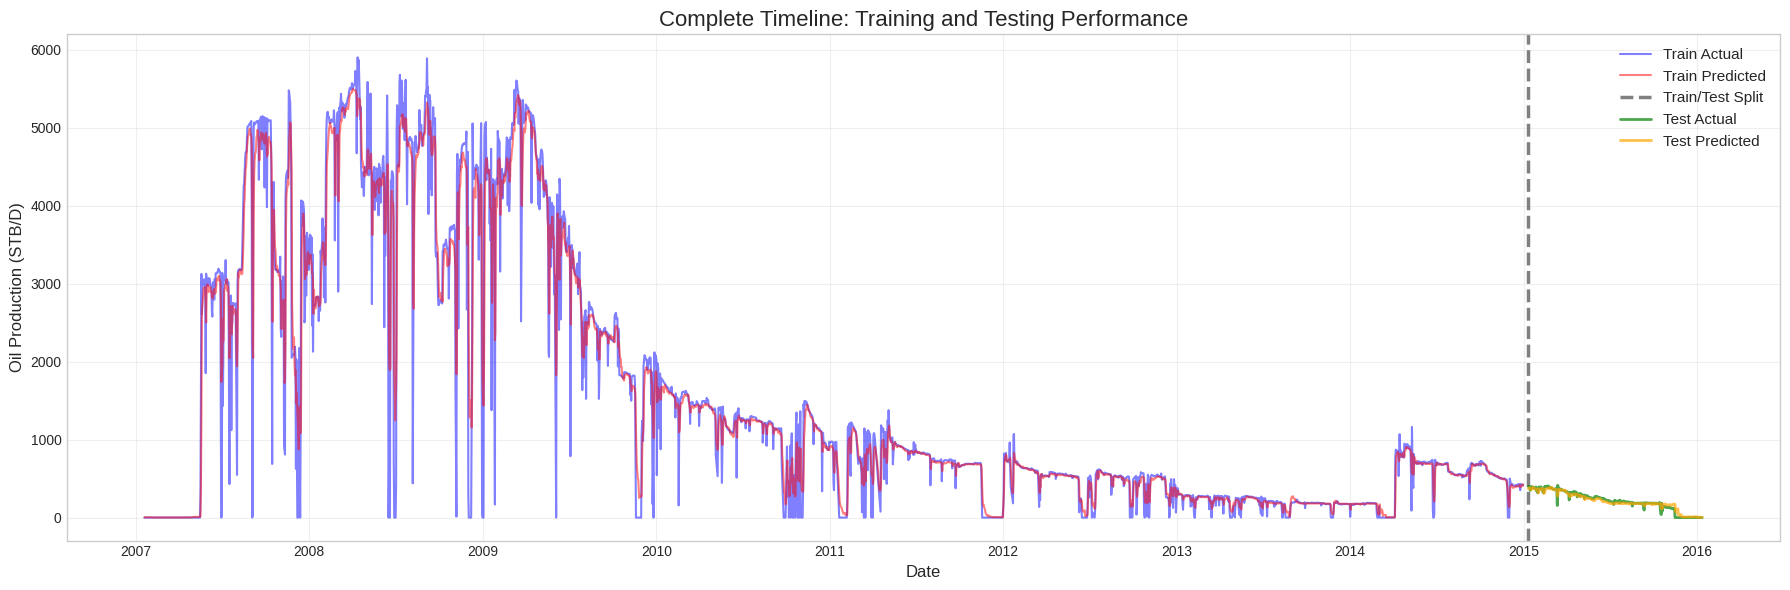

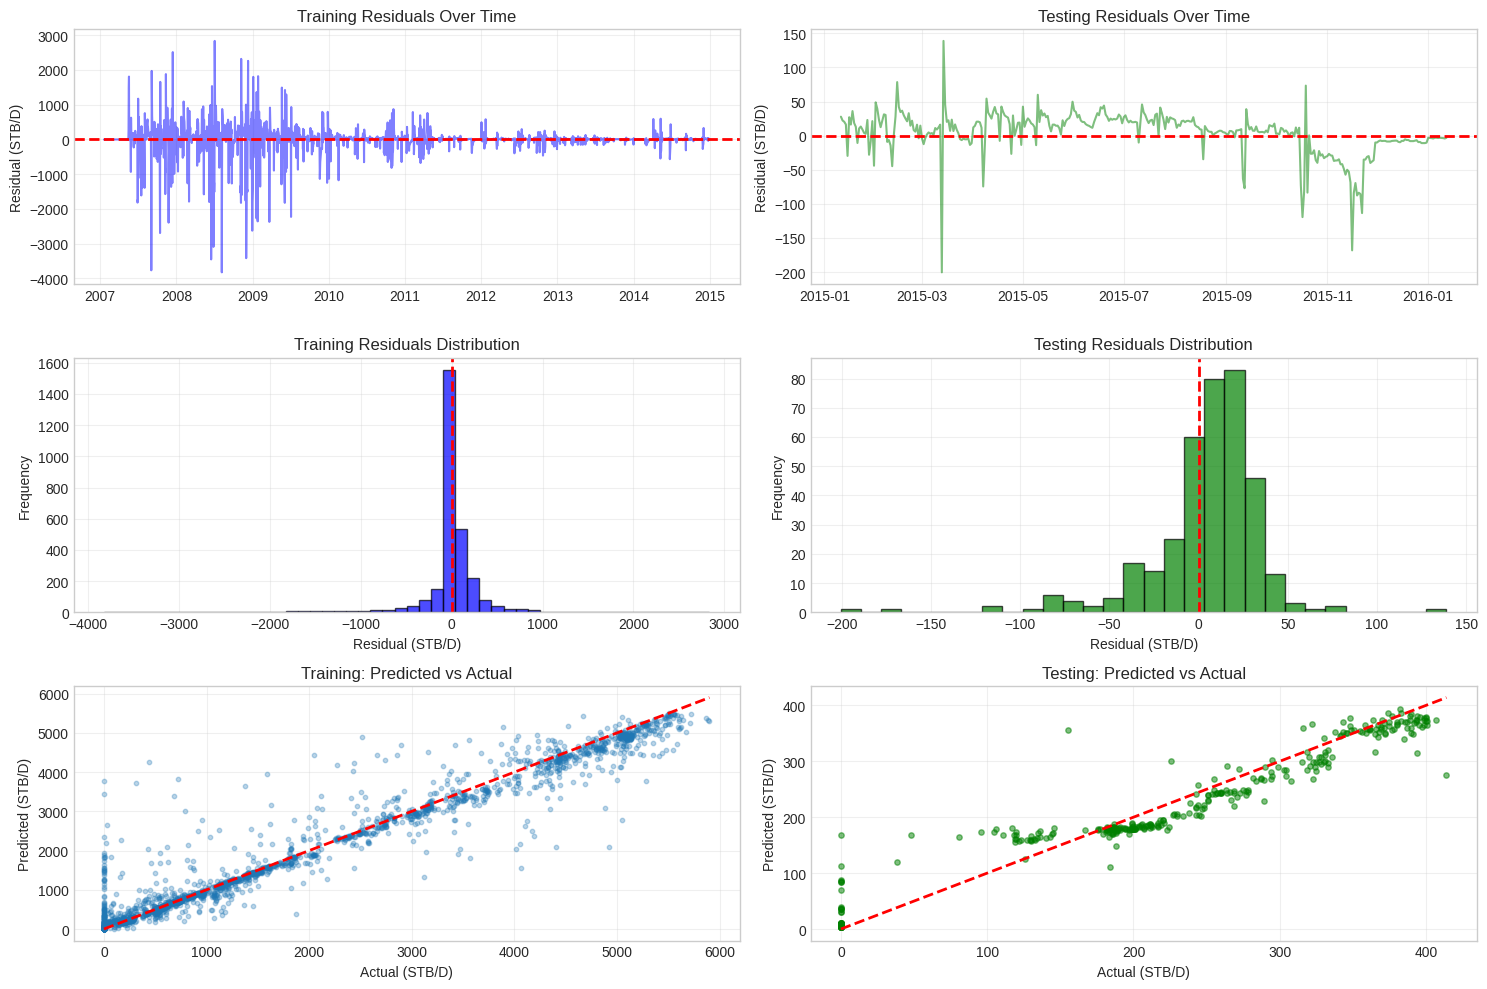

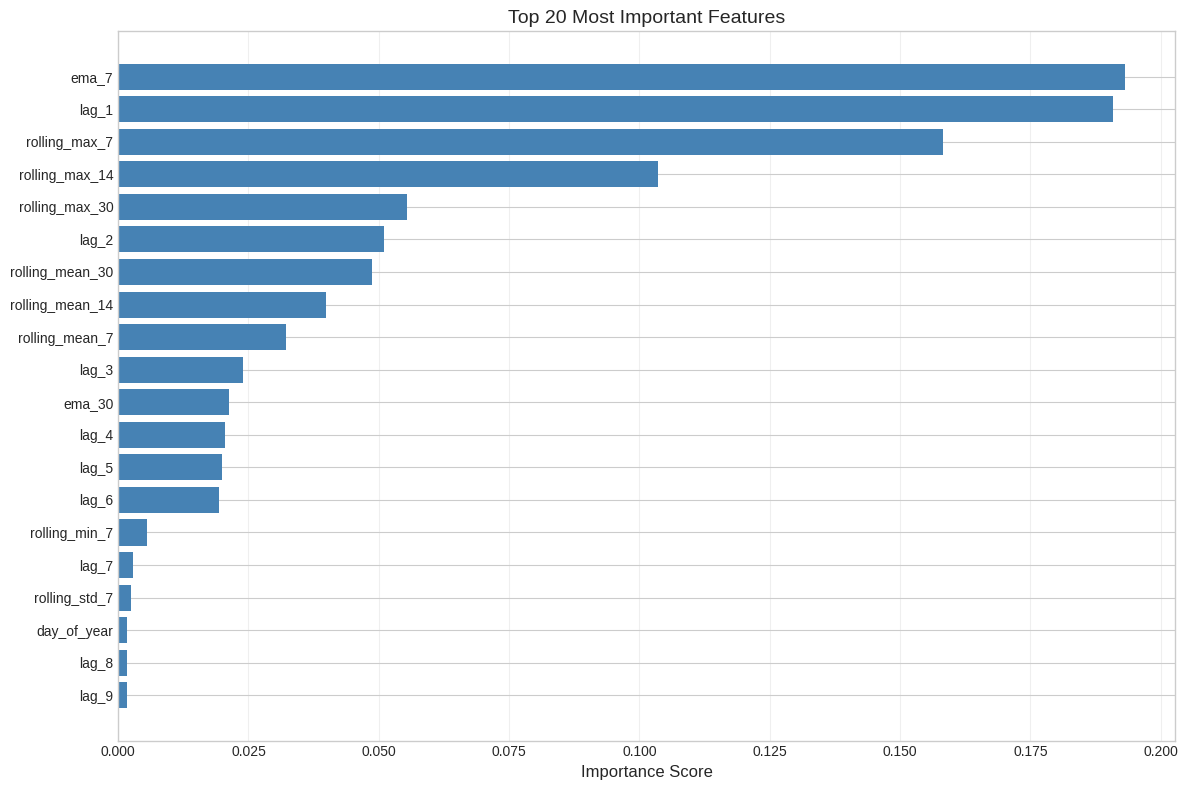


FEATURE IMPORTANCE (Top 15)
        feature  importance
          ema_7    0.193126
          lag_1    0.190790
  rolling_max_7    0.158158
 rolling_max_14    0.103601
 rolling_max_30    0.055505
          lag_2    0.050936
rolling_mean_30    0.048716
rolling_mean_14    0.039850
 rolling_mean_7    0.032155
          lag_3    0.023965
         ema_30    0.021341
          lag_4    0.020478
          lag_5    0.019859
          lag_6    0.019443
  rolling_min_7    0.005516


In [28]:
print("\n[8/8] Creating visualizations...")

# Figure 1: Training Set Performance
plt.figure(figsize=(15, 5))
plt.plot(X_train.index, y_train, 'b-', alpha=0.7, linewidth=1.5, label='Actual (Training)')
plt.plot(X_train.index, yp_train, 'r-', alpha=0.7, linewidth=1.5, label='Predicted (Training)')
plt.title(f'Training Set Performance (RMSE: {train_rmse:.2f}, R²: {train_r2:.3f})', size=16)
plt.xlabel('Date', size=12)
plt.ylabel('Oil Production (STB/D)', size=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Test Set Performance
plt.figure(figsize=(15, 5))
plt.plot(X_test.index, y_test, 'g-', alpha=0.7, linewidth=1.5, label='Actual (Testing)')
plt.plot(X_test.index, yp_test, 'orange', alpha=0.7, linewidth=1.5, label='Predicted (Testing)')
plt.title(f'Test Set Performance (RMSE: {test_rmse:.2f}, R²: {test_r2:.3f})', size=16)
plt.xlabel('Date', size=12)
plt.ylabel('Oil Production (STB/D)', size=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 3: Complete Timeline
plt.figure(figsize=(18, 6))
plt.plot(X_train.index, y_train, 'b-', alpha=0.5, linewidth=1.5, label='Train Actual')
plt.plot(X_train.index, yp_train, 'r-', alpha=0.5, linewidth=1.5, label='Train Predicted')
plt.axvline(X_test.index[0], color='gray', linestyle='--', linewidth=2.5, label='Train/Test Split')
plt.plot(X_test.index, y_test, 'g-', alpha=0.7, linewidth=2, label='Test Actual')
plt.plot(X_test.index, yp_test, 'orange', alpha=0.7, linewidth=2, label='Test Predicted')
plt.title('Complete Timeline: Training and Testing Performance', size=16)
plt.xlabel('Date', size=12)
plt.ylabel('Oil Production (STB/D)', size=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 4: Residual Analysis
plt.figure(figsize=(15, 10))

# Residuals over time - Training
plt.subplot(3, 2, 1)
residuals_train = y_train - yp_train
plt.plot(X_train.index, residuals_train, 'b-', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Training Residuals Over Time')
plt.ylabel('Residual (STB/D)')
plt.grid(True, alpha=0.3)

# Residuals over time - Testing
plt.subplot(3, 2, 2)
residuals_test = y_test - yp_test
plt.plot(X_test.index, residuals_test, 'g-', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Testing Residuals Over Time')
plt.ylabel('Residual (STB/D)')
plt.grid(True, alpha=0.3)

# Residual histogram - Training
plt.subplot(3, 2, 3)
plt.hist(residuals_train, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title('Training Residuals Distribution')
plt.xlabel('Residual (STB/D)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Residual histogram - Testing
plt.subplot(3, 2, 4)
plt.hist(residuals_test, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title('Testing Residuals Distribution')
plt.xlabel('Residual (STB/D)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Predicted vs Actual - Training
plt.subplot(3, 2, 5)
plt.scatter(y_train, yp_train, alpha=0.3, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=2)
plt.title('Training: Predicted vs Actual')
plt.xlabel('Actual (STB/D)')
plt.ylabel('Predicted (STB/D)')
plt.grid(True, alpha=0.3)

# Predicted vs Actual - Testing
plt.subplot(3, 2, 6)
plt.scatter(y_test, yp_test, alpha=0.5, s=15, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Testing: Predicted vs Actual')
plt.xlabel('Actual (STB/D)')
plt.ylabel('Predicted (STB/D)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 5: Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(range(top_n), feature_importance['importance'][:top_n], color='steelblue')
plt.yticks(range(top_n), feature_importance['feature'][:top_n])
plt.xlabel('Importance Score', size=12)
plt.title(f'Top {top_n} Most Important Features', size=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (Top 15)")
print("=" * 80)
print(feature_importance.head(15).to_string(index=False))
print("=" * 80)

# ============================================
# OPTIONAL: SAVE MODEL
# ============================================

In [37]:
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("\nKey Improvements Implemented:")
print("✓ Proper train-test split (no data leakage)")
print("✓ Multiple lagged features (10 lags)")
print("✓ Rolling statistics and moving averages")
print("✓ Model regularization to prevent overfitting")
print("✓ Comprehensive evaluation metrics")
print("✓ Residual analysis")
print("✓ Feature importance analysis")
print("\nYour model is now ready for production forecasting!")
print("=" * 80)


ANALYSIS COMPLETE!

Key Improvements Implemented:
✓ Proper train-test split (no data leakage)
✓ Multiple lagged features (10 lags)
✓ Rolling statistics and moving averages
✓ Model regularization to prevent overfitting
✓ Comprehensive evaluation metrics
✓ Residual analysis
✓ Feature importance analysis

Your model is now ready for production forecasting!


# Optional: Display summary statistics

In [38]:
print("\nSummary Statistics:")
print(f"  - Training Data Mean: {y_train.mean():.2f} STB/D")
print(f"  - Training Data Std:  {y_train.std():.2f} STB/D")
print(f"  - Testing Data Mean:  {y_test.mean():.2f} STB/D")
print(f"  - Testing Data Std:   {y_test.std():.2f} STB/D")
print(f"  - Mean Absolute % Error (Test): {(test_mae / y_test.mean() * 100):.2f}%")


Summary Statistics:
  - Training Data Mean: 1560.41 STB/D
  - Training Data Std:  1685.83 STB/D
  - Testing Data Mean:  214.78 STB/D
  - Testing Data Std:   122.62 STB/D
  - Mean Absolute % Error (Test): 10.42%
